# Batch Metrics Computation for HPE Results

This notebook processes all CSV files in the `csv_batch` folder, computes PCK, RMSE, and MPJPE metrics for each dataset by comparing predictions to ground truth, and aggregates total averages across all datasets.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from pathlib import Path
from datasets.utils import constants as ds_constants, parsing as ds_parsing
from evaluation.utils import metrics as metrics_utils

# List All CSV Files in Folder

In [18]:
csv_folder = Path('/home/moveEnetFlow/csv_file/moveEnetOFK_test/op0.005_np0.01_fp0.001/')

# Initialize Metric Accumulators

In [19]:
thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())

pck_accum = {th: [] for th in thresholds}
pck_per_joint_accum = {th: [] for th in thresholds}
rmse_per_joint_accum = []
rmse_total_accum = []
mpjpe_per_joint_accum = []
mpjpe_total_accum = []

# Datasets with corrupted GT we want to drop from evaluation
exclude_datasets = {"cam4_S11_Greeting", "cam4_S9_Eating", "cam4_S9_SittingDown_1","cam4_S9_Walking", "cam4_S9_Waiting_1", "cam4_S9_Photo", "cam4_S9_Photo_1", "cam4_S9_Greeting"}

# Prepare Data for All Datasets

In [20]:
# Prepare data for all datasets
all_joints_pred = []
all_joints_gt = []
all_pck_sizes = []
all_valid_masks = []
dataset_names = []

for csv_file in csv_folder.glob('*.csv'):
    dirname = csv_file.stem
    if dirname in exclude_datasets:
        print(f"Skipping {csv_file.name} (excluded dataset)")
        continue
    
    print(f"Preparing data for {csv_file.name}...")
    
    # Load CSV Data
    predictions = np.loadtxt(csv_file, delimiter=',', skiprows=1)
    ts_pred = predictions[:, 0]
    lat_pred = predictions[:, 1]
    joints_pred = predictions[:, 2:28].reshape(-1, 13, 2)
    
    # Load Corresponding Ground Truth Data
    gt_path = Path('/data/new_scarfGNN_full/raw') / dirname / 'ch0GT200Hzskeleton' / 'data.log'
    data = ds_parsing.import_yarp_skeleton_data(gt_path, multi_channel=False)
    
    # Extract Joint Trajectories
    ts_gt = np.concatenate(([0.0], data['ts'], [data['ts'][-1] + 1]))
    for joint_key in ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys():
        x_interp = interpolate.interp1d(ts_gt, np.concatenate(([data[joint_key][0, 0]], data[joint_key][:, 0], [data[joint_key][-1, 0]])), bounds_error=False, fill_value='extrapolate')
        y_interp = interpolate.interp1d(ts_gt, np.concatenate(([data[joint_key][0, 1]], data[joint_key][:, 1], [data[joint_key][-1, 1]])), bounds_error=False, fill_value='extrapolate')
        data[joint_key] = {'x': x_interp, 'y': y_interp}
    
    # Clip prediction timestamps to GT range to avoid extreme extrapolation
    ts_pred = np.clip(ts_pred, ts_gt[0], ts_gt[-1])
    
    joints_gt = np.zeros((len(ts_pred), 13, 2))
    joint_list = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
    for i, ts in enumerate(ts_pred):
        for j, joint in enumerate(joint_list):
            joints_gt[i, j, 0] = data[joint]['x'](ts)
            joints_gt[i, j, 1] = data[joint]['y'](ts)
    
    # Mark massive sentinel GT values as missing (-1) and track validity mask
    sentinel_mask = np.abs(joints_gt) > 1e6
    if np.any(sentinel_mask):
        print(f"    Warning: found {np.count_nonzero(sentinel_mask)} extreme GT values; marking as missing.")
        joints_gt[sentinel_mask] = -1.0
    valid_mask = (joints_gt[:, :, 0] >= 0) & (joints_gt[:, :, 1] >= 0)
    
    # Check for NaN or Inf
    if np.any(np.isnan(joints_gt)) or np.any(np.isinf(joints_gt)) or np.any(np.isnan(joints_pred)) or np.any(np.isinf(joints_pred)):
        print(f"    Skipping {csv_file.name} due to NaN/Inf")
        continue
    
    # Prepare PCK sizes
    if data['head_sizes'][0] != -1:
        pck_sizes_interp = interpolate.interp1d(ts_gt, np.concatenate(([data['head_sizes'][0]], data['head_sizes'], [data['head_sizes'][-1]])), bounds_error=False, fill_value='extrapolate')
    else:
        pck_sizes_interp = interpolate.interp1d(ts_gt, np.concatenate(([data['torso_sizes'][0]], data['torso_sizes'], [data['torso_sizes'][-1]])), bounds_error=False, fill_value='extrapolate')
    pck_sizes = pck_sizes_interp(ts_pred)
    
    # Store prepared data
    all_joints_pred.append(joints_pred)
    all_joints_gt.append(joints_gt)
    all_pck_sizes.append(pck_sizes)
    all_valid_masks.append(valid_mask)
    dataset_names.append(csv_file.name)
    
    print(f"  Prepared data for {csv_file.name}")

print(f"Data preparation complete for {len(dataset_names)} datasets.")

Preparing data for cam2_S1_Discussion.csv...
  Prepared data for cam2_S1_Discussion.csv
Preparing data for cam2_S1_Eating.csv...
  Prepared data for cam2_S1_Eating.csv
Preparing data for cam2_S1_Phoning.csv...
  Prepared data for cam2_S1_Phoning.csv
Preparing data for cam2_S1_Waiting.csv...
  Prepared data for cam2_S1_Waiting.csv
Preparing data for cam2_S1_WalkingDog.csv...
  Prepared data for cam2_S1_WalkingDog.csv
Preparing data for cam2_S1_Sitting_1.csv...
  Prepared data for cam2_S1_Sitting_1.csv
Preparing data for cam2_S1_Walking.csv...
  Prepared data for cam2_S1_Walking.csv
Preparing data for cam2_S1_Purchases.csv...
  Prepared data for cam2_S1_Purchases.csv
Preparing data for cam2_S1_WalkTogether.csv...
  Prepared data for cam2_S1_WalkTogether.csv
Preparing data for cam2_S1_Directions.csv...
  Prepared data for cam2_S1_Directions.csv
Preparing data for cam2_S1_SittingDown.csv...
  Prepared data for cam2_S1_SittingDown.csv
Preparing data for cam2_S1_TakingPhoto.csv...
  Prepared

# Loop Over Each CSV File

In [21]:
# Loop Over Each CSV File for PCK
for i, name in enumerate(dataset_names):
    print(f"Processing {name} for PCK...")
    
    joints_pred = all_joints_pred[i]
    joints_gt = all_joints_gt[i]
    pck_sizes = all_pck_sizes[i]
    
    # Compute PCK Metric
    for th in thresholds:
        pck_metric = metrics_utils.PCK(th)
        pck_metric.update_samples(joints_pred, joints_gt, pck_sizes)
        pck_results = pck_metric.get_value()
        pck_accum[th].append(pck_results[1])  # Overall PCK
        pck_per_joint_accum[th].append(pck_results[0])  # Per-joint PCK
    
    print(f"  Completed PCK for {name}")

print("PCK computation done.")

Processing cam2_S1_Discussion.csv for PCK...
  Completed PCK for cam2_S1_Discussion.csv
Processing cam2_S1_Eating.csv for PCK...
  Completed PCK for cam2_S1_Eating.csv
Processing cam2_S1_Phoning.csv for PCK...
  Completed PCK for cam2_S1_Phoning.csv
Processing cam2_S1_Waiting.csv for PCK...
  Completed PCK for cam2_S1_Waiting.csv
Processing cam2_S1_WalkingDog.csv for PCK...
  Completed PCK for cam2_S1_WalkingDog.csv
Processing cam2_S1_Sitting_1.csv for PCK...
  Completed PCK for cam2_S1_Sitting_1.csv
Processing cam2_S1_Walking.csv for PCK...
  Completed PCK for cam2_S1_Walking.csv
Processing cam2_S1_Purchases.csv for PCK...
  Completed PCK for cam2_S1_Purchases.csv
Processing cam2_S1_WalkTogether.csv for PCK...
  Completed PCK for cam2_S1_WalkTogether.csv
Processing cam2_S1_Directions.csv for PCK...
  Completed PCK for cam2_S1_Directions.csv
Processing cam2_S1_SittingDown.csv for PCK...
  Completed PCK for cam2_S1_SittingDown.csv
Processing cam2_S1_TakingPhoto.csv for PCK...
  Complete

# Compute RMSE Metrics

In [22]:
# Loop Over Each CSV File for RMSE
for i, name in enumerate(dataset_names):
    print(f"Processing {name} for RMSE...")
    
    joints_pred = all_joints_pred[i]
    joints_gt = all_joints_gt[i]
    
    # Compute RMSE Metric
    rmse_metric = metrics_utils.RMSE()
    rmse_metric.update_samples(joints_pred, joints_gt)
    rmse_results = rmse_metric.get_value()
    # Debug: Check shapes and values
    print(f"    RMSE Debug - joints_pred shape: {joints_pred.shape}, joints_gt shape: {joints_gt.shape}")
    print(f"    RMSE Debug - joints_pred sample: {joints_pred[0, :3]}")  # First 3 joints of first frame
    print(f"    RMSE Debug - joints_gt sample: {joints_gt[0, :3]}")  # First 3 joints of first frame
    print(f"    RMSE Debug - rmse_results: {rmse_results}")
    print(f"    RMSE Debug - per-joint RMSE sample: {rmse_results[2][:3]}")  # First 3 joints
    rmse_per_joint_accum.append(rmse_results[2])
    rmse_total_accum.append(rmse_results[2].mean())
    
    print(f"  Completed RMSE for {name}")

print("RMSE computation done.")

Processing cam2_S1_Discussion.csv for RMSE...
    RMSE Debug - joints_pred shape: (15420, 13, 2), joints_gt shape: (15420, 13, 2)
    RMSE Debug - joints_pred sample: [[325.265106  93.225067]
 [310.859344 123.650368]
 [350.702148 121.889854]]
    RMSE Debug - joints_gt sample: [[331.  90.]
 [309. 123.]
 [364. 123.]]
    RMSE Debug - rmse_results: (array([1.07265297, 2.7909416 , 1.10923783, 2.0769023 , 1.2639651 ,
       2.18080273, 1.87384894, 3.32940832, 1.40515718, 3.94905656,
       1.06265698, 1.33889808, 0.95084646, 1.73917842, 3.52239215,
       6.95644532, 2.75005141, 7.4590044 , 1.21153762, 1.41477241,
       1.31239426, 1.29941181, 1.88619217, 1.49122151, 1.54012767,
       1.24865657]), array([1.61238929, 2.86728462]), array([2.7909416 , 2.0769023 , 2.18080273, 3.32940832, 3.94905656,
       1.33889808, 1.73917842, 6.95644532, 7.4590044 , 1.41477241,
       1.31239426, 1.88619217, 1.54012767]))
    RMSE Debug - per-joint RMSE sample: [2.7909416  2.0769023  2.18080273]
  Compl

# Compute MPJPE Metrics

In [23]:
# Loop Over Each CSV File for MPJPE
for i, name in enumerate(dataset_names):
    print(f"Processing {name} for MPJPE...")
    
    joints_pred = all_joints_pred[i]
    joints_gt = all_joints_gt[i]
    
    # Compute MPJPE Metric
    mpjpe_metric = metrics_utils.MPJPE()
    mpjpe_metric.update_samples(joints_pred, joints_gt)
    mpjpe_results = mpjpe_metric.get_value()
    # Debug: Check shapes and values
    print(f"    MPJPE Debug - mpjpe_results: {mpjpe_results}")
    print(f"    MPJPE Debug - per-joint MPJPE sample: {mpjpe_results[0][:3]}")  # First 3 joints
    mpjpe_per_joint_accum.append(mpjpe_results[0])
    mpjpe_total_accum.append(mpjpe_results[1])
    
    print(f"  Completed MPJPE for {name}")

print("MPJPE computation done.")

Processing cam2_S1_Discussion.csv for MPJPE...
    MPJPE Debug - mpjpe_results: (array([ 3.26045221,  3.24122102,  4.27665718,  6.11000029,  6.85587893,
        4.19830899,  4.15518965, 12.64351971, 13.29908352,  4.71504166,
        4.86458595,  6.57145843,  5.65243334]), 6.141833143820526)
    MPJPE Debug - per-joint MPJPE sample: [3.26045221 3.24122102 4.27665718]
  Completed MPJPE for cam2_S1_Discussion.csv
Processing cam2_S1_Eating.csv for MPJPE...
    MPJPE Debug - mpjpe_results: (array([ 3.84621956,  4.65645628,  3.9132621 ,  6.43535992,  7.04249672,
        5.26406316,  5.36940544, 10.40050034, 12.12544477,  6.92289881,
        7.77791448,  8.52037166, 10.95595024]), 7.171564883879951)
    MPJPE Debug - per-joint MPJPE sample: [3.84621956 4.65645628 3.9132621 ]
  Completed MPJPE for cam2_S1_Eating.csv
Processing cam2_S1_Phoning.csv for MPJPE...
    MPJPE Debug - mpjpe_results: (array([ 4.28845303,  5.63313779,  4.84163316,  7.10747714,  6.17764934,
        5.16031979,  4.8730668

# Display Aggregated Results

In [24]:
# Ensure variables are defined (run this if kernel was restarted)
if 'pck_accum' not in globals():
    thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
    joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
    pck_accum = {th: [] for th in thresholds}
    pck_per_joint_accum = {th: [] for th in thresholds}
    rmse_per_joint_accum = []
    rmse_total_accum = []
    mpjpe_per_joint_accum = []
    mpjpe_total_accum = []

# Compute averages
print("Aggregated Metrics Across All Datasets:")
print("=" * 50)

# PCK Averages
print("PCK Results (Overall and Per-Joint Average %):")
print("-" * 50)
for th in thresholds:
    avg_pck = np.mean(pck_accum[th]) * 100
    print(f"Threshold {th:.2f} - Overall: {avg_pck:.2f}%")
    pck_per_joint_avg = np.mean(np.array(pck_per_joint_accum[th]), axis=0) * 100
    for i, name in enumerate(joint_names):
        print(f"{name}: {pck_per_joint_avg[i]:.2f}%")
    print()
print("-" * 50)

# RMSE Averages
rmse_per_joint_avg = np.mean(np.array(rmse_per_joint_accum), axis=0)
rmse_total_avg = np.mean(rmse_total_accum)
print("RMSE Results (pixels):")
print("-" * 40)
for i, name in enumerate(joint_names):
    print(f"{name}: {rmse_per_joint_avg[i]:.2f}")
print("-" * 40)
print(f"Total Average RMSE: {rmse_total_avg:.2f} pixels")
print("-" * 40)

# MPJPE Averages
mpjpe_per_joint_avg = np.mean(np.array(mpjpe_per_joint_accum), axis=0)
mpjpe_total_avg = np.mean(mpjpe_total_accum)
print("MPJPE Results (pixels):")
print("-" * 40)
for i, name in enumerate(joint_names):
    print(f"{name}: {mpjpe_per_joint_avg[i]:.2f}")
print("-" * 40)
print(f"Total Average MPJPE: {mpjpe_total_avg:.2f} pixels")
print("-" * 40)

Aggregated Metrics Across All Datasets:
PCK Results (Overall and Per-Joint Average %):
--------------------------------------------------
Threshold 0.20 - Overall: 95.46%
head: 99.16%
shoulder_right: 99.27%
shoulder_left: 99.14%
elbow_right: 95.86%
elbow_left: 96.09%
hip_left: 98.85%
hip_right: 98.93%
wrist_right: 86.54%
wrist_left: 87.68%
knee_right: 97.71%
knee_left: 95.98%
ankle_right: 92.93%
ankle_left: 92.84%

Threshold 0.25 - Overall: 97.54%
head: 99.48%
shoulder_right: 99.62%
shoulder_left: 99.51%
elbow_right: 98.03%
elbow_left: 97.78%
hip_left: 99.62%
hip_right: 99.54%
wrist_right: 92.90%
wrist_left: 93.19%
knee_right: 98.91%
knee_left: 97.57%
ankle_right: 96.10%
ankle_left: 95.72%

Threshold 0.30 - Overall: 98.55%
head: 99.68%
shoulder_right: 99.82%
shoulder_left: 99.73%
elbow_right: 99.02%
elbow_left: 98.70%
hip_left: 99.85%
hip_right: 99.76%
wrist_right: 95.93%
wrist_left: 96.07%
knee_right: 99.48%
knee_left: 98.46%
ankle_right: 97.43%
ankle_left: 97.25%

Threshold 0.35 - Ov

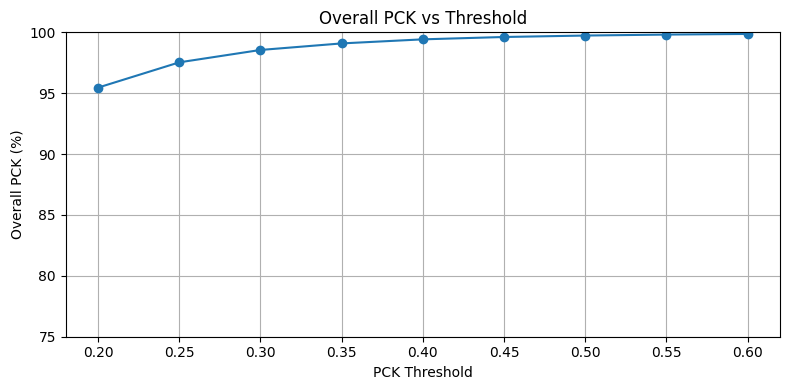

: 

In [ ]:
# Plot overall PCK percentage versus threshold
overall_pck_percent = []
valid_thresholds = []
for th in thresholds:
    values = pck_accum.get(th, [])
    if len(values) == 0:
        continue
    valid_thresholds.append(th)
    overall_pck_percent.append(np.mean(values) * 100)
if len(valid_thresholds) == 0:
    raise RuntimeError("No PCK data available to plot. Run the metric aggregation cells first.")
plt.figure(figsize=(8, 4))
plt.plot(valid_thresholds, overall_pck_percent, marker='o')
plt.xlabel('PCK Threshold')
plt.ylabel('Overall PCK (%)')
plt.title('Overall PCK vs Threshold')
plt.ylim(75, 100)
plt.grid(True)
plt.tight_layout()
plt.show()